Compare % habitability for all parameters

In [5]:
# Import necessary libraries

import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

Create indices for each parameter and x-axes

In [35]:
# Rotation
rot_indices = [0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.75,2.0]
x_rot = np.round(rot_indices,3)

# Flux
flux_indices = [0.1,0.25,0.5,0.75,1.0,1.25]
x_flux = np.round(flux_indices,3)

# Pressure
pressure_indices = [0.5,0.75,1.0,1.25,1.5,1.75,2.0]
x_pressure = np.round(pressure_indices,3)

# Gravity
grav_indices = [0.5,0.75,1.0,1.25,1.50,1.75]
x_grav = np.round(grav_indices,3)

# Tilt
tilt_indices = [0,10,20,30,40,50,60,70,80]
x_tilt = np.round(tilt_indices,3)

Identify paths to files

In [36]:
rot_file = "../rotation/{}.nc"
flux_file = "../solarflux/{}.nc"
pressure_file = "../pressure/{}.nc"
grav_file = "../gravity/{}.nc"
tilt_file = "../axialtilt/{}.nc"

Write a function that exracts results from each file

In [38]:
def file_open(file_template, file_indices):

    # Create an empty results container
    results = {
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        }

    for idx in file_indices:
        fname = file_template.format(idx)

        # Ensure file exists
        if not Path(fname).exists():
            print(f"Warning: {fname} not found, skipping")
            continue

        # Open the dataset and process
        ds = xr.open_dataset(fname)
        data = ds.sel(time=slice("2001-01-01", "2002-01-01"))

        # Obtain habitable fractions
        fraction_sm = Habitability.fraction(data, "sm")[0]
        fraction_st = Habitability.fraction(data, "st")[0]
        fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
        sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
        sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]

        # Append habitability values to results
        results["sm_tot"].append(fraction_sm)
        results["st_tot"].append(fraction_st)
        results["tsurf_tot"].append(fraction_tsurf)
        results["sm_nhem"].append(sm_n)
        results["st_nhem"].append(st_n)
        results["tsurf_nhem"].append(tsurf_n)
        results["sm_shem"].append(sm_s)
        results["st_shem"].append(st_s)
        results["tsurf_shem"].append(tsurf_s)
        
    # Convert lists to numpy arrays
    for k in results:
        if results[k] is None:
            continue
        if isinstance(results[k], list):
            results[k] = np.array(results[k])

    return results

Extract results for each parameter using the helper function

In [39]:
rot_data = file_open(rot_file, rot_indices)
flux_data = file_open(flux_file, flux_indices)
pressure_data = file_open(pressure_file, pressure_indices)
grav_data = file_open(grav_file, grav_indices)
tilt_data = file_open(tilt_file, tilt_indices)

Plot the data

In [40]:
# Global plot for soil temperature habitability

y_rot = rot_data["st_tot"]
y_flux = flux_data["st_tot"]
y_pressure = pressure_data["st_tot"]
y_grav = grav_data["st_tot"]
y_tilt = tilt_data["st_tot"]


x_tilt_mod = x_tilt / 23.4

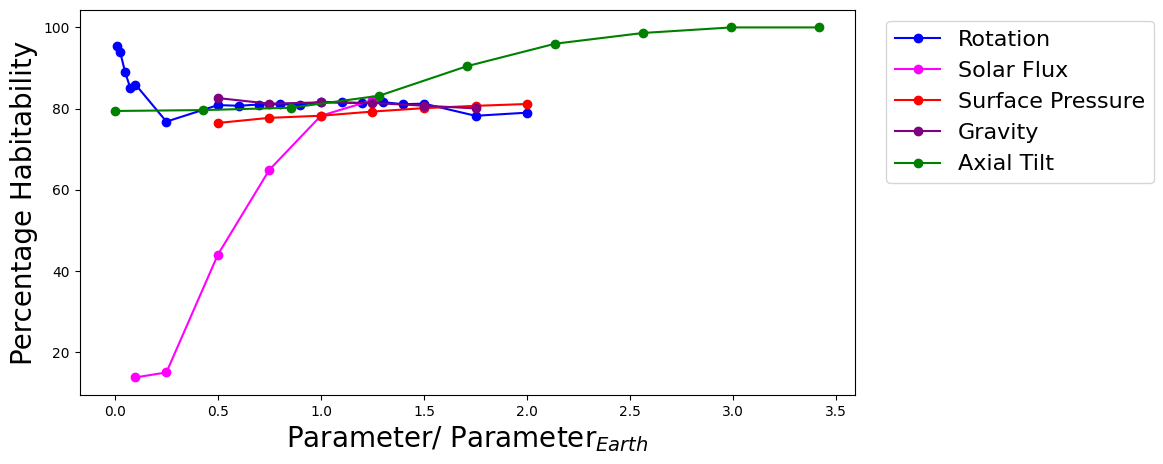

In [41]:
fig = plt.figure(figsize=(10,5))
plt.plot(x_rot, y_rot, marker='o', label="Rotation", color="blue")
plt.plot(x_flux, y_flux, marker='o', label="Solar Flux", color='magenta')
plt.plot(x_pressure, y_pressure, marker='o', label="Surface Pressure", color='red')
plt.plot(x_grav, y_grav, marker='o', label="Gravity", color='purple')
plt.plot(x_tilt_mod, y_tilt, marker='o', label="Axial Tilt", color='green')
plt.xlabel("Parameter/ Parameter$_{Earth}$", fontsize=20)
plt.ylabel("Percentage Habitability", fontsize=20)
plt.legend(loc="upper right", fontsize=16, bbox_to_anchor=(1.4, 1))
plt.show()